<a href="https://colab.research.google.com/github/HaruWatXXD67/quant-projects/blob/main/bayesian_beta_binomial_conjugate_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.optimize as opt
import scipy.stats as st
from IPython.display import display
import math
from scipy.stats import beta
from scipy.optimize import fmin

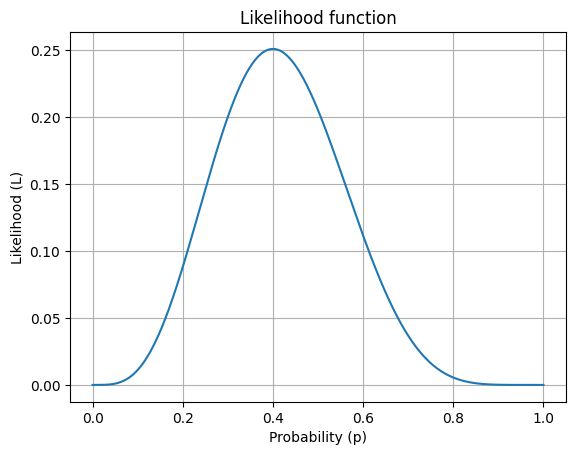

Likelihood Ratio :1.2230590464


In [2]:
c = math.comb(10, 4)

# Likelihood function
def likelihood_func(p):
    return  c * p**4 * (1-p)**6

p = np.linspace(0, 1, 1000)

L = likelihood_func(p)

plt.plot(p, L)
plt.title("Likelihood function")
plt.xlabel("Probability (p)")
plt.ylabel("Likelihood (L)")
plt.grid()
plt.show()

a = likelihood_func(0.4)
b = likelihood_func(0.5)
print("Likelihood Ratio :" + str(a/b))

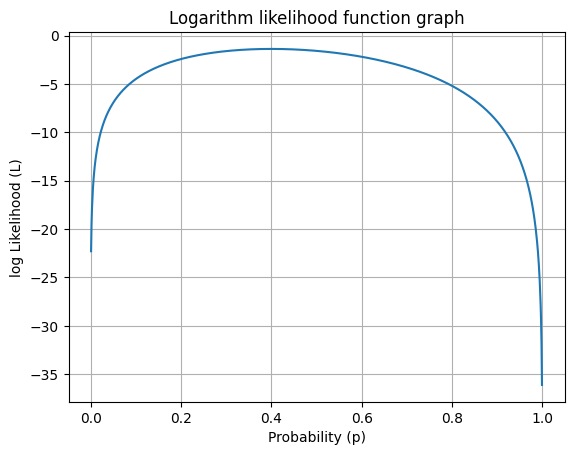

Value when p = 0.35 :-1.4368784638319685
Value when p = 0.4 :-1.3830091393750958
Value when p = 0.45 :-1.4339452586873405


In [3]:
#Logarithm Likelihood
def logarithm_likelihood_func(p):
    return np.log(210) + 4 * np.log(p) + 6 * np.log(1-p)

p = np.linspace(0.001, 0.999, 1000)

logL = logarithm_likelihood_func(p)

plt.plot(p, logL)
plt.title("Logarithm likelihood function graph")
plt.xlabel("Probability (p)")
plt.ylabel("log Likelihood (L)")
plt.grid()
plt.show()

print("Value when p = 0.35 :" + str(logarithm_likelihood_func(0.35)))
print("Value when p = 0.4 :" + str(logarithm_likelihood_func(0.4)))
print("Value when p = 0.45 :" + str(logarithm_likelihood_func(0.45)))

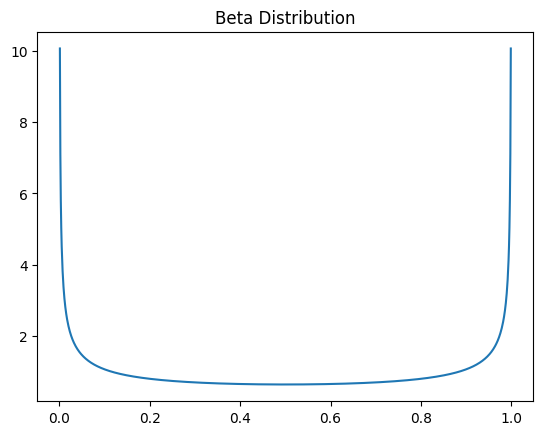

In [4]:
# Beta Distribution
from scipy.stats import beta

# Parameters
a, b = 0.5, 0.5

x = np.linspace(0, 1, 1000)
y = beta.pdf(x, a, b)
plt.plot(x, y)
plt.title('Beta Distribution')
plt.show()

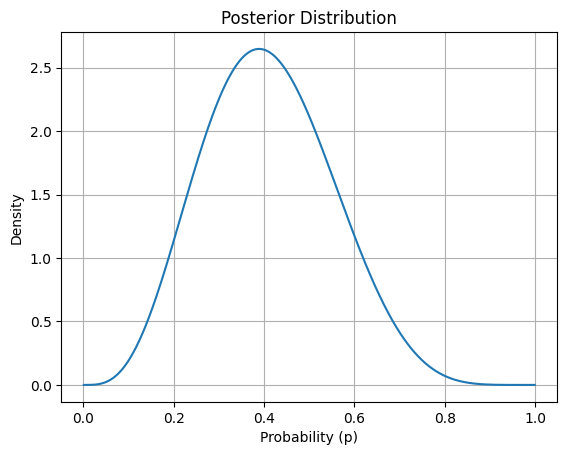

In [5]:
x = 4
n = 10
a = 0.5
b = 0.5
posterior_a = a + x
posterior_b = b + n - x
posterior = beta.pdf(p, posterior_a, posterior_b)


plt.plot(p, posterior)
plt.title('Posterior Distribution')
plt.xlabel('Probability (p)')
plt.ylabel('Density')
plt.grid(True)
plt.show()

In [7]:
# Define Parameters
x = 4
n = 10
a = 0.5
b = 0.5
posterior_a = a + x
posterior_b = b + n - x

#Posterior Mean, Variance, Median, Mode
posterior_pdf = beta(posterior_a, posterior_b)
posterior_mean = posterior_pdf.mean()
posterior_var = posterior_pdf.var()
posterior_med = posterior_pdf.ppf(0.5)
posterior_mode = (posterior_a - 1)/(posterior_a + posterior_b - 2)

print(f"Posterior Mean: {posterior_mean}")
print(f"Posterior Variance: {posterior_var}")
print(f"Posterior Median: {posterior_med}")
print(f"Posterior Mode: {posterior_mode}")

Posterior Mean: 0.4090909090909091
Posterior Variance: 0.020144628099173553
Posterior Median: 0.4033924804501068
Posterior Mode: 0.3888888888888889


In [8]:
# Confirm analytically
posterior_mean = (posterior_a)/(posterior_a + posterior_b)
posterior_var = (posterior_a)*(posterior_b)/((posterior_a + posterior_b)**2 * (posterior_a + posterior_b + 1))
posterior_med_approx = (posterior_a -1/3)/(posterior_a + posterior_b - 2/3)

def f(x):
    return beta.pdf(x, posterior_a, posterior_b)
result = fmin(lambda x: -f(x), 0, disp = False)
posterior_mode_approx = result[0]

print(posterior_mean)
print(posterior_var)
print(posterior_med_approx)
print(posterior_mode_approx)

0.4090909090909091
0.020144628099173553
0.40322580645161293
0.38887500000000036
